In [6]:
# Importing necessary libraries for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn



In [7]:
# Step 1: Load and Understand the Dataset

import pandas as pd

# Load the dataset (replace 'your_file.csv' with the actual file path)
df = pd.read_csv('data/data.csv')

# Inspect the structure of the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Display first few rows of the dataset
print("\nFirst Few Rows:")
print(df.head())


Dataset Shape: (95662, 16)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 

In [8]:
# Step 2: Create Aggregate Features

# Total Transaction Amount per Customer
df['TotalTransactionAmount'] = df.groupby('CustomerId')['Amount'].transform('sum')

# Average Transaction Amount per Customer
df['AverageTransactionAmount'] = df.groupby('CustomerId')['Amount'].transform('mean')

# Transaction Count per Customer
df['TransactionCount'] = df.groupby('CustomerId')['TransactionId'].transform('count')

# Standard Deviation of Transaction Amounts per Customer
df['StdTransactionAmount'] = df.groupby('CustomerId')['Amount'].transform('std')

# Verify the new features
print("Aggregate Features Preview:")
print(df[['CustomerId', 'TotalTransactionAmount', 'AverageTransactionAmount', 'TransactionCount', 'StdTransactionAmount']].head())


Aggregate Features Preview:
        CustomerId  TotalTransactionAmount  AverageTransactionAmount  \
0  CustomerId_4406               109921.75                923.712185   
1  CustomerId_4406               109921.75                923.712185   
2  CustomerId_4683                 1000.00                500.000000   
3   CustomerId_988               228727.20               6019.136842   
4   CustomerId_988               228727.20               6019.136842   

   TransactionCount  StdTransactionAmount  
0               119           3042.294251  
1               119           3042.294251  
2                 2              0.000000  
3                38          17169.241610  
4                38          17169.241610  


In [9]:
# Step 2: Extract Time-Based Features

# Convert TransactionStartTime to datetime format
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Extract Transaction Hour
df['TransactionHour'] = df['TransactionStartTime'].dt.hour

# Extract Transaction Day
df['TransactionDay'] = df['TransactionStartTime'].dt.day

# Extract Transaction Month
df['TransactionMonth'] = df['TransactionStartTime'].dt.month

# Extract Transaction Year
df['TransactionYear'] = df['TransactionStartTime'].dt.year

# Verify the new features
print("Time-Based Features Preview:")
print(df[['TransactionStartTime', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear']].head())


Time-Based Features Preview:
       TransactionStartTime  TransactionHour  TransactionDay  \
0 2018-11-15 02:18:49+00:00                2              15   
1 2018-11-15 02:19:08+00:00                2              15   
2 2018-11-15 02:44:21+00:00                2              15   
3 2018-11-15 03:32:55+00:00                3              15   
4 2018-11-15 03:34:21+00:00                3              15   

   TransactionMonth  TransactionYear  
0                11             2018  
1                11             2018  
2                11             2018  
3                11             2018  
4                11             2018  


In [10]:
# Importing necessary module
import category_encoders as ce

# Define categorical columns for WOE transformation
categorical_columns = ['ProductCategory', 'ProviderId', 'ChannelId']

# Create WOE encoder
woe_encoder = ce.WOEEncoder(cols=categorical_columns)

In [11]:
# Importing necessary module
import category_encoders as ce

# Define categorical columns for WOE transformation
categorical_columns = ['ProviderId']  # Only ProviderId needs WOE encoding

# Initialize WOEEncoder
woe_encoder = ce.WOEEncoder(cols=categorical_columns)

# Fit and transform WOE encoder on data
woe_encoded = woe_encoder.fit_transform(df[categorical_columns], df['FraudResult'])

# Rename WOE encoded columns
woe_encoded.columns = [f"{col}_WOE" for col in categorical_columns]

# Drop original categorical columns and merge WOE encoded columns
df = df.drop(columns=categorical_columns).reset_index(drop=True)
df = pd.concat([df, woe_encoded], axis=1)

# Preview the dataset after WOE encoding
print("WOE Encoded Features Preview:")
print(df.head())

WOE Encoded Features Preview:
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode     ProductId  \
0  CustomerId_4406          UGX          256  ProductId_10   
1  CustomerId_4406          UGX          256   ProductId_6   
2  CustomerId_4683          UGX          256   ProductId_1   
3   CustomerId_988          UGX          256  ProductId_21   
4   CustomerId_988          UGX          256   ProductId_6   

      ProductCategory    ChannelId  ...  FraudResult  TotalTransactionAmount  \
0             airtime  ChannelId_3  ...   

In [12]:
# Selecting the relevant WOE-encoded features and other necessary columns for the model
columns_to_use = [
    'Amount', 'Value', 'TotalTransactionAmount', 'AverageTransactionAmount',
    'TransactionCount', 'StdTransactionAmount', 'TransactionHour', 'TransactionDay',
    'TransactionMonth', 'TransactionYear', 'ProviderId_WOE'
]

# Creating a new dataframe for model input
model_data = df[columns_to_use]

# Displaying the prepared data for modeling
print("Model Data Preview:")
print(model_data.head())


Model Data Preview:
    Amount  Value  TotalTransactionAmount  AverageTransactionAmount  \
0   1000.0   1000               109921.75                923.712185   
1    -20.0     20               109921.75                923.712185   
2    500.0    500                 1000.00                500.000000   
3  20000.0  21800               228727.20               6019.136842   
4   -644.0    644               228727.20               6019.136842   

   TransactionCount  StdTransactionAmount  TransactionHour  TransactionDay  \
0               119           3042.294251                2              15   
1               119           3042.294251                2              15   
2                 2              0.000000                2              15   
3                38          17169.241610                3              15   
4                38          17169.241610                3              15   

   TransactionMonth  TransactionYear  ProviderId_WOE  
0                11          

In [13]:
# Step 5: Normalize/Standardize Numerical Features

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns
numerical_columns = ['TotalTransactionAmount', 'AverageTransactionAmount', 
                     'TransactionCount', 'StdTransactionAmount', 'Amount', 'Value']

# Create scalers
normalizer = MinMaxScaler()
standardizer = StandardScaler()

# Normalize features (range [0, 1])
df_normalized = df.copy()
df_normalized[numerical_columns] = normalizer.fit_transform(df[numerical_columns])

# Standardize features (mean 0, std 1)
df_standardized = df.copy()
df_standardized[numerical_columns] = standardizer.fit_transform(df[numerical_columns])

# Preview normalized and standardized datasets
print("Normalized Features Preview:\n", df_normalized[numerical_columns].head())
print("\nStandardized Features Preview:\n", df_standardized[numerical_columns].head())


Normalized Features Preview:
    TotalTransactionAmount  AverageTransactionAmount  TransactionCount  \
0                0.557522                  0.047184          0.028851   
1                0.557522                  0.047184          0.028851   
2                0.556944                  0.047137          0.000244   
3                0.558153                  0.047749          0.009046   
4                0.558153                  0.047749          0.009046   

   StdTransactionAmount    Amount     Value  
0              0.000919  0.092004  0.000101  
1              0.000919  0.091910  0.000002  
2              0.000000  0.091958  0.000050  
3              0.005187  0.093750  0.002206  
4              0.005187  0.091853  0.000065  

Standardized Features Preview:
    TotalTransactionAmount  AverageTransactionAmount  TransactionCount  \
0                0.170118                 -0.067623         -0.311831   
1                0.170118                 -0.067623         -0.311831   
2  

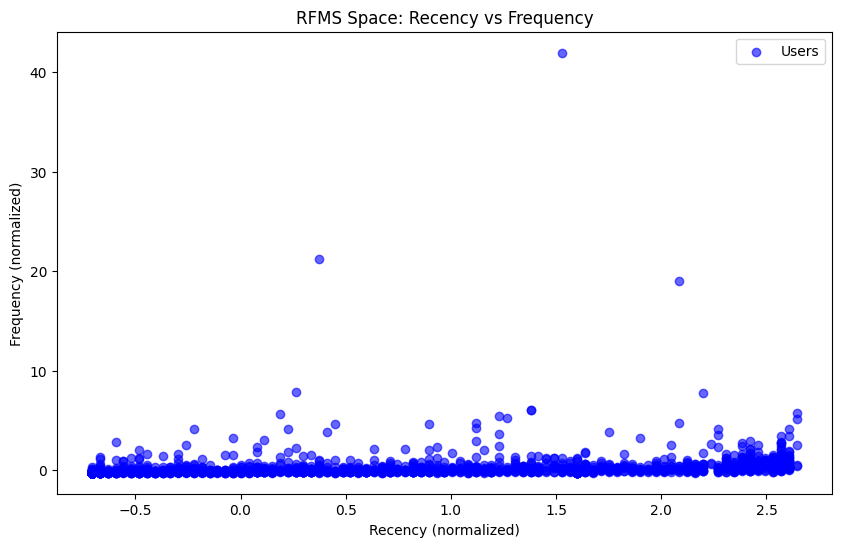

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Calculate RFMS metrics
rfms_data = (
    df.groupby('CustomerId')
    .agg(
        Recency=('TransactionStartTime', lambda x: (x.max() - x.min()).days),
        Frequency=('TransactionId', 'count'),
        Monetary=('Amount', 'sum'),
        Stability=('StdTransactionAmount', 'mean')
    )
    .reset_index()
)

# Normalize RFMS metrics for clustering and visualization
rfms_data[['Recency', 'Frequency', 'Monetary', 'Stability']] = rfms_data[
    ['Recency', 'Frequency', 'Monetary', 'Stability']
].apply(lambda x: (x - x.mean()) / x.std())

# Visualize RFMS space
plt.figure(figsize=(10, 6))
plt.scatter(rfms_data['Recency'], rfms_data['Frequency'], c='blue', alpha=0.6, label='Users')
plt.title('RFMS Space: Recency vs Frequency')
plt.xlabel('Recency (normalized)')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()

# Optional: Cluster users to establish boundaries
kmeans = KMeans(n_clusters=2, random_state=42)
rfms_data['RFMS_Cluster'] = kmeans.fit_predict(rfms_data[['Recency', 'Frequency', 'Monetary', 'Stability']])

# Plot clusters
plt.figure(figsize=(10, 6))
for cluster in rfms_data['RFMS_Cluster'].unique():
    subset = rfms_data[rfms_data['RFMS_Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Frequency'], alpha=0.6, label=f'Cluster {cluster}')
plt.title('RFMS Space: Clusters')
plt.xlabel('Recency (normalized)')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()


In [18]:
plt.figure(figsize=(10, 6))
for cluster in rfms_data['RFMS_Cluster'].unique():
    subset = rfms_data[rfms_data['RFMS_Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Frequency'], alpha=0.6, label=f'Cluster {cluster}')
plt.title('RFMS Space: Clusters')
plt.xlabel('Recency (normalized)')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()

KeyError: 'RFMS_Cluster'

<Figure size 1000x600 with 0 Axes>

C:\Users\Hp\AppData\Local\Temp\ipykernel_7704\3045508857.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfms_data_cleaned['RFMS_Cluster'] = kmeans.fit_predict(rfms_data_cleaned[['Recency', 'Frequency', 'Monetary', 'Stability']])


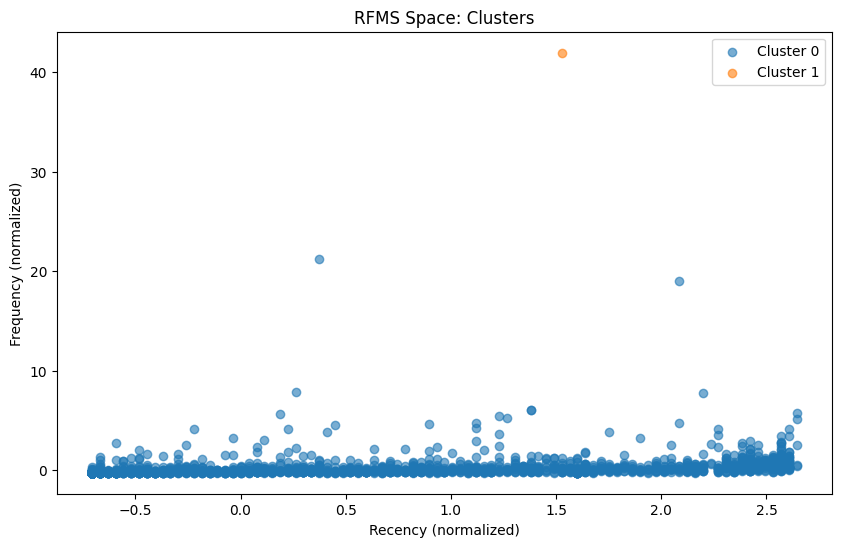

In [16]:
# Drop rows with NaN values
rfms_data_cleaned = rfms_data.dropna()

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
rfms_data_cleaned['RFMS_Cluster'] = kmeans.fit_predict(rfms_data_cleaned[['Recency', 'Frequency', 'Monetary', 'Stability']])

# Plot clusters
plt.figure(figsize=(10, 6))
for cluster in rfms_data_cleaned['RFMS_Cluster'].unique():
    subset = rfms_data_cleaned[rfms_data_cleaned['RFMS_Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Frequency'], alpha=0.6, label=f'Cluster {cluster}')
plt.title('RFMS Space: Clusters')
plt.xlabel('Recency (normalized)')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()

CustomerId      0
Recency         0
Frequency       0
Monetary        0
Stability     712
dtype: int64
CustomerId    0
Recency       0
Frequency     0
Monetary      0
Stability     0
dtype: int64


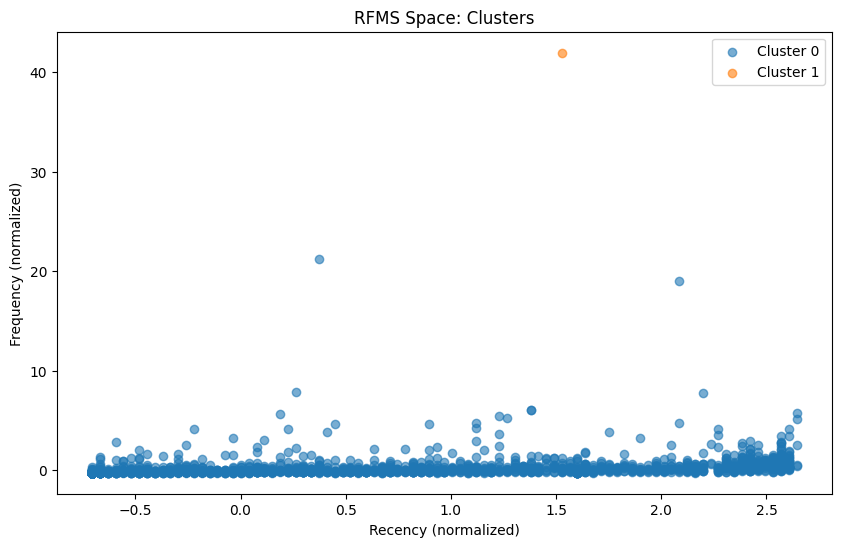

In [20]:
# Check for missing values
print(rfms_data.isnull().sum())

# Impute missing values with the mean for numeric columns only
numeric_columns = rfms_data.select_dtypes(include=[np.number]).columns
rfms_data[numeric_columns] = rfms_data[numeric_columns].fillna(rfms_data[numeric_columns].mean())

# Verify no missing values remain
print(rfms_data.isnull().sum())

# Re-run clustering after handling missing values
kmeans = KMeans(n_clusters=2, random_state=42)
rfms_data['RFMS_Cluster'] = kmeans.fit_predict(rfms_data[['Recency', 'Frequency', 'Monetary', 'Stability']])

# Plot clusters
plt.figure(figsize=(10, 6))
for cluster in rfms_data['RFMS_Cluster'].unique():
    subset = rfms_data[rfms_data['RFMS_Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Frequency'], alpha=0.6, label=f'Cluster {cluster}')
plt.title('RFMS Space: Clusters')
plt.xlabel('Recency (normalized)')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_7704\1940715664.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rfms_data['Stability'].fillna(rfms_data['Stability'].mean(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_7704\1940715664.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfms_data, x='Cluster', y='Stability', palette='deep')
C:\Users\Hp\AppData\Local\

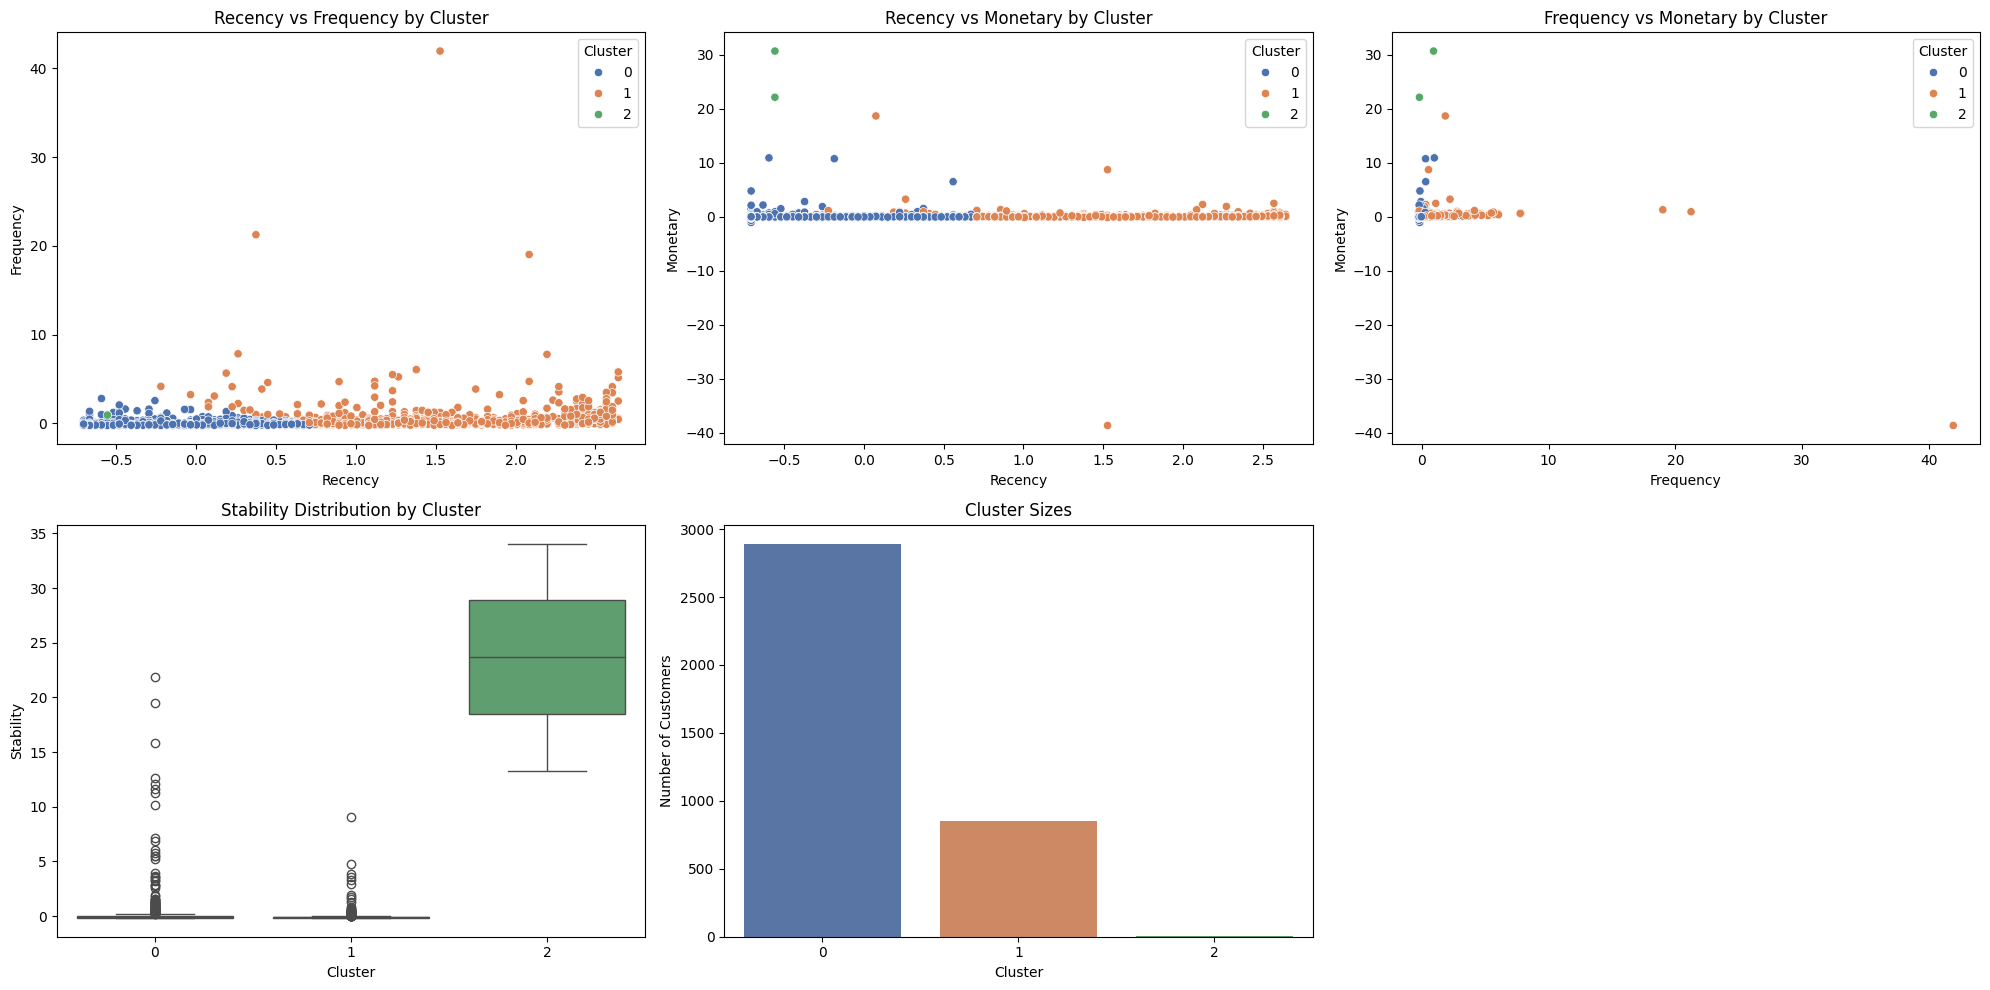


Cluster Characteristics:
        Recency       Frequency       Monetary       Stability       
           mean   std      mean   std     mean   std      mean    std
Cluster                                                              
0         -0.49  0.36     -0.17  0.18    -0.03  0.35     -0.00   0.88
1          1.65  0.66      0.56  1.97     0.03  1.52     -0.05   0.46
2         -0.56  0.00      0.37  0.79    26.37  6.05     23.66  14.72

Cluster Sizes:
Cluster
0    2887
1     853
2       2
Name: count, dtype: int64


In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Calculate RFMS metrics
rfms_data = (
    df.groupby('CustomerId')
    .agg(
        Recency=('TransactionStartTime', lambda x: (x.max() - x.min()).days),
        Frequency=('TransactionId', 'count'),
        Monetary=('Amount', 'sum'),
        Stability=('StdTransactionAmount', 'mean')
    )
    .reset_index()
)

# Handle missing values in Stability with mean
rfms_data['Stability'].fillna(rfms_data['Stability'].mean(), inplace=True)

# Normalize RFMS metrics
rfms_features = ['Recency', 'Frequency', 'Monetary', 'Stability']
rfms_data[rfms_features] = rfms_data[rfms_features].apply(lambda x: (x - x.mean()) / x.std())

# Perform K-means clustering
n_clusters = 3  # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
rfms_data['Cluster'] = kmeans.fit_predict(rfms_data[rfms_features])

# Create visualization
plt.figure(figsize=(20, 10))

# Plot 1: Recency vs Frequency
plt.subplot(2, 3, 1)
sns.scatterplot(data=rfms_data, x='Recency', y='Frequency', hue='Cluster', palette='deep')
plt.title('Recency vs Frequency by Cluster')

# Plot 2: Recency vs Monetary
plt.subplot(2, 3, 2)
sns.scatterplot(data=rfms_data, x='Recency', y='Monetary', hue='Cluster', palette='deep')
plt.title('Recency vs Monetary by Cluster')

# Plot 3: Frequency vs Monetary
plt.subplot(2, 3, 3)
sns.scatterplot(data=rfms_data, x='Frequency', y='Monetary', hue='Cluster', palette='deep')
plt.title('Frequency vs Monetary by Cluster')

# Plot 4: Stability Distribution
plt.subplot(2, 3, 4)
sns.boxplot(data=rfms_data, x='Cluster', y='Stability', palette='deep')
plt.title('Stability Distribution by Cluster')

# Plot 5: Cluster Sizes
plt.subplot(2, 3, 5)
cluster_sizes = rfms_data['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='deep')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

# Print cluster characteristics
print("\nCluster Characteristics:")
cluster_stats = rfms_data.groupby('Cluster')[rfms_features].agg(['mean', 'std']).round(2)
print(cluster_stats)

# Calculate and print cluster sizes
print("\nCluster Sizes:")
print(rfms_data['Cluster'].value_counts().sort_index())

# Optional: Save clustered data
rfms_data.to_csv('rfms_clusters.csv', index=False)

In [22]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.model_selection import train_test_split

# Load and inspect the dataset
# Ensure the dataset includes columns: ['CustomerId', 'Recency', 'Frequency', 'Monetary', 'Stability', 'Cluster']
print("Dataset preview:")
print(rfms_data.head())

# Rename 'Cluster' to 'RFMS_Cluster' if necessary
rfms_data.rename(columns={"Cluster": "RFMS_Cluster"}, inplace=True)

# Assign Target labels
rfms_data['Target'] = rfms_data['RFMS_Cluster'].apply(lambda x: 1 if x == 0 else 0)

# Select features for WoE binning
features = ['Recency', 'Frequency', 'Monetary', 'Stability']

# Split data into training and testing sets
train, test = train_test_split(
    rfms_data, 
    test_size=0.3, 
    random_state=42, 
    stratify=rfms_data['Target']
)

# Ensure no unsupported data types are in the dataframe
def clean_columns(df):
    for col in df.columns:
        # Convert numpy arrays to tuples or strings
        if df[col].apply(lambda x: isinstance(x, np.ndarray)).any():
            df[col] = df[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) else x)
        # Convert other unhashable types if necessary
        df[col] = df[col].astype(str) if not pd.api.types.is_hashable(df[col].iloc[0]) else df[col]
    return df

# Clean train and test dataframes
train = clean_columns(train)
test = clean_columns(test)

# Perform WoE binning
print("Performing WoE binning...")
bins = sc.woebin(
    train,
    y='Target',
    x=features,
    method='chimerge', 
    min_perc_fine_bin=0.05, 
    min_perc_coarse_bin=0.1
)

# Inspect the structure of the `bins` object
print("Type of bins:", type(bins))
if isinstance(bins, dict):
    print("Bins is a dictionary with keys:", bins.keys())
elif isinstance(bins, list):
    print("Bins is a list with length:", len(bins))
else:
    print("Bins is of unexpected type:", type(bins))

# Clean the bins object to ensure no unhashable types are present
def clean_bins(bins):
    if isinstance(bins, dict):
        # If bins is a dictionary, clean each DataFrame in the dictionary
        for key, bin_df in bins.items():
            for col in bin_df.columns:
                if bin_df[col].apply(lambda x: isinstance(x, np.ndarray)).any():
                    bin_df[col] = bin_df[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) else x)
                if not pd.api.types.is_hashable(bin_df[col].iloc[0]):
                    bin_df[col] = bin_df[col].astype(str)
            bins[key] = bin_df
    elif isinstance(bins, list):
        # If bins is a list, clean each DataFrame in the list
        for i, bin_df in enumerate(bins):
            for col in bin_df.columns:
                if bin_df[col].apply(lambda x: isinstance(x, np.ndarray)).any():
                    bin_df[col] = bin_df[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) else x)
                if not pd.api.types.is_hashable(bin_df[col].iloc[0]):
                    bin_df[col] = bin_df[col].astype(str)
            bins[i] = bin_df
    else:
        raise ValueError("Unexpected type for bins. Expected dict or list of DataFrames.")
    return bins

# Clean the bins object
bins = clean_bins(bins)

# Apply WoE transformation
print("Applying WoE transformation...")
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

# Drop original features after transformation
train_woe = train_woe.drop(columns=features)
test_woe = test_woe.drop(columns=features)

# Display WoE-transformed data
print("Transformed training data preview:")
print(train_woe.head())

print("Transformed testing data preview:")
print(test_woe.head())

# Save results if needed
train_woe.to_csv("train_woe.csv", index=False)
test_woe.to_csv("test_woe.csv", index=False)
print("WoE-transformed data saved to 'train_woe.csv' and 'test_woe.csv'.")

Dataset preview:
        CustomerId   Recency  Frequency  Monetary  Stability  Cluster
0     CustomerId_1 -0.705593  -0.253425 -0.066882   0.000000        0
1    CustomerId_10 -0.705593  -0.253425 -0.066882   0.000000        0
2  CustomerId_1001 -0.705593  -0.212158 -0.055841  -0.105962        0
3  CustomerId_1002  1.638884  -0.150258 -0.061647  -0.168014        1
4  CustomerId_1003 -0.705593  -0.201841 -0.055841  -0.111429        0
Performing WoE binning...
[INFO] creating woe binning ...


c:\Users\Hp\Videos\Bati Bank\env\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Hp\Videos\Bati Bank\env\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Hp\Videos\Bati Bank\env\Lib\site-packages\scorecardpy\woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future vers

Type of bins: <class 'dict'>
Bins is a dictionary with keys: dict_keys(['Recency', 'Frequency', 'Monetary', 'Stability'])
Applying WoE transformation...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
Transformed training data preview:
      Target  RFMS_Cluster       CustomerId
560        1             0  CustomerId_1762
138        1             0  CustomerId_1197
2689       1             0  CustomerId_4537
1636       1             0  CustomerId_3242
1644       1             0  CustomerId_3251
Transformed testing data preview:
      Target  RFMS_Cluster       CustomerId
3441       1             0   CustomerId_710
1179       1             0  CustomerId_2668
2461       1             0  CustomerId_4260
942        1             0  CustomerId_2334
2084       0             1  CustomerId_3787
WoE-transformed data saved to 'train_woe.csv' and 'test_woe.csv'.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report

# Drop non-numeric columns (e.g., CustomerId)
X_train = train_woe.drop(columns=['Target', 'CustomerId'])  # Exclude non-numeric
y_train = train_woe['Target']

X_test = test_woe.drop(columns=['Target', 'CustomerId'])  # Exclude non-numeric
y_test = test_woe['Target']

# Define and train logistic regression model
print("Training logistic regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Evaluate model on test data
print("Evaluating logistic regression model...")
y_pred = lr_model.predict(X_test)

# Generate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training logistic regression model...
Evaluating logistic regression model...
Precision: 1.00
Recall: 1.00
Confusion Matrix:
[[257   0]
 [  0 866]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       1.00      1.00      1.00       866

    accuracy                           1.00      1123
   macro avg       1.00      1.00      1.00      1123
weighted avg       1.00      1.00      1.00      1123



In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report

# Drop non-numeric columns (e.g., CustomerId)
X_train = train_woe.drop(columns=['Target', 'CustomerId'])  # Exclude non-numeric
y_train = train_woe['Target']

X_test = test_woe.drop(columns=['Target', 'CustomerId'])  # Exclude non-numeric
y_test = test_woe['Target']

# Define and train logistic regression model
print("Training logistic regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Evaluate model on test data
print("Evaluating logistic regression model...")
y_pred = lr_model.predict(X_test)

# Generate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training logistic regression model...
Evaluating logistic regression model...
Precision: 1.00
Recall: 1.00
Confusion Matrix:
[[257   0]
 [  0 866]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       1.00      1.00      1.00       866

    accuracy                           1.00      1123
   macro avg       1.00      1.00      1.00      1123
weighted avg       1.00      1.00      1.00      1123



In [25]:

rfms_data['Target'] = (rfms_data['Recency'] > 0).astype(int)  # Replace with your logic


In [26]:
print(rfms_data.head())


        CustomerId   Recency  Frequency  Monetary  Stability  RFMS_Cluster  \
0     CustomerId_1 -0.705593  -0.253425 -0.066882   0.000000             0   
1    CustomerId_10 -0.705593  -0.253425 -0.066882   0.000000             0   
2  CustomerId_1001 -0.705593  -0.212158 -0.055841  -0.105962             0   
3  CustomerId_1002  1.638884  -0.150258 -0.061647  -0.168014             1   
4  CustomerId_1003 -0.705593  -0.201841 -0.055841  -0.111429             0   

   Target  
0       0  
1       0  
2       0  
3       1  
4       0  


In [27]:
from sklearn.model_selection import train_test_split

# Define features and target
X = rfms_data.drop(columns=['Target'])
y = rfms_data['Target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
def classify_customer(row):
    if row['Recency'] < 0 and row['Frequency'] > 0 and row['Monetary'] > 0 and row['Stability'] > 0:
        return 1  # Good
    else:
        return 0  # Bad

rfms_data['Target'] = rfms_data.apply(classify_customer, axis=1)

# Check the class balance
print("Class Distribution:")
print(rfms_data['Target'].value_counts())


Class Distribution:
Target
0    3728
1      14
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Drop the 'CustomerId' column
X = rfms_data.drop(columns=['CustomerId'])  # Remove irrelevant identifier column
y = rfms_data['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new class distribution
from collections import Counter
print(f"Class distribution after SMOTE: {Counter(y_train_resampled)}")


Class distribution after SMOTE: Counter({0: 2609, 1: 2609})


In [30]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Balanced Class Distribution:")
print(pd.Series(y_train_balanced).value_counts())

Balanced Class Distribution:
Target
0    2609
1    2609
Name: count, dtype: int64


In [31]:
# Check the shape of the resampled datasets
print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)

# Check the class distribution
from collections import Counter
print("Class distribution in y_train_resampled:", Counter(y_train_resampled))


X_train_resampled shape: (5218, 6)
y_train_resampled shape: (5218,)
Class distribution in y_train_resampled: Counter({0: 2609, 1: 2609})


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize models
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
random_forest_model = RandomForestClassifier(random_state=42)

# Train models
logistic_model.fit(X_train_resampled, y_train_resampled)
random_forest_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Calculate probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
print("Logistic Regression:")
print(classification_report(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))

# Evaluate Random Forest
print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1119
           1       0.67      1.00      0.80         4

    accuracy                           1.00      1123
   macro avg       0.83      1.00      0.90      1123
weighted avg       1.00      1.00      1.00      1123

ROC-AUC: 0.9991063449508489
Confusion Matrix:
 [[1117    2]
 [   0    4]]

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1119
           1       1.00      1.00      1.00         4

    accuracy                           1.00      1123
   macro avg       1.00      1.00      1.00      1123
weighted avg       1.00      1.00      1.00      1123

ROC-AUC: 1.0
Confusion Matrix:
 [[1119    0]
 [   0    4]]


In [33]:
import joblib

# Save the Random Forest model to a file
model_filename = 'random_forest_model.pkl'
joblib.dump(random_forest_model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to random_forest_model.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required at each leaf node
    'bootstrap': [True, False]        # Whether bootstrap samples are used
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters from Grid Search:", best_params)

# Train the model with the best parameters
best_rf_model = grid_search.best_estimator_

Best Parameters from Grid Search: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
